In [ ]:
##Day#3

In [ ]:
#environment setup
%%capture
!pip install ---upgrade openai tiktoken pandas tabulate

In [ ]:
# Environment Setup
%%capture
!pip install --upgrade openai tiktoken pandas tabulate

import os
from getpass import getpass

api_key = None

# Try Colab's Secrets manager first
try:
    from google.colab import userdata
    api_key = userdata.get('OPENAI_KEY')
except Exception:
    api_key = None

# Fall back to environment variable, then manual entry
if not api_key:
    api_key = os.environ.get("OPENAI_KEY") or os.environ.get("OPENAI_API_KEY")

if not api_key:
    api_key = getpass("Enter your OPENAI_KEY (input hidden): ")

os.environ["OPENAI_KEY"] = api_key
os.environ["OPENAI_API_KEY"] = api_key  # the SDK looks for this name by default

print("✅ API key loaded:", "*" * 8 + api_key[-4:] if len(api_key) > 4 else "set")

In [ ]:
from openai import OpenAI

client = OpenAI(api_key=os.environ["OPENAI_KEY"])
print("Client ready.")

FOUNDATIONAL_MODEL = "gpt-4o-mini"   # swap for "gpt-4o" for a stronger non-reasoning baseline
REASONING_MODEL    = "o4-mini"        # swap for "o3" for a stronger reasoning model

print(f"Foundational model : {FOUNDATIONAL_MODEL}")
print(f"Reasoning model    : {REASONING_MODEL}")

Client ready.


In [ ]:
import time

def call_foundational(prompt, model=FOUNDATIONAL_MODEL, temperature=0.2, max_tokens=800):
    start = time.time()
    resp = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=temperature,
        max_tokens=max_tokens,
    )
    elapsed = time.time() - start
    return {
        "model": model,
        "type": "foundational",
        "answer": resp.choices[0].message.content,
        "elapsed_sec": round(elapsed, 2),
        "prompt_tokens": resp.usage.prompt_tokens,
        "completion_tokens": resp.usage.completion_tokens,
        "reasoning_tokens": 0,
        "total_tokens": resp.usage.total_tokens,
    }

def call_reasoning(prompt, model=REASONING_MODEL, reasoning_effort="medium", max_completion_tokens=2000):
    start = time.time()
    resp = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        reasoning_effort=reasoning_effort,
        max_completion_tokens=max_completion_tokens,
    )
    elapsed = time.time() - start
    usage = resp.usage
    reasoning_tokens = 0
    details = getattr(usage, "completion_tokens_details", None)
    if details is not None:
        reasoning_tokens = getattr(details, "reasoning_tokens", 0) or 0
    return {
        "model": model,
        "type": "reasoning",
        "answer": resp.choices[0].message.content,
        "elapsed_sec": round(elapsed, 2),
        "prompt_tokens": usage.prompt_tokens,
        "completion_tokens": usage.completion_tokens,
        "reasoning_tokens": reasoning_tokens,
        "total_tokens": usage.total_tokens,
    }

In [ ]:
#Prompt Definition containing the 3 problem domains.
prompts = {
    "logic_puzzle": (
        "Five friends (Ana, Ben, Cara, Dan, Ella) sit in a row of 5 seats "
        "numbered 1 to 5 left to right. Clues: "
        "(1) Ana sits immediately left of Ben. "
        "(2) Cara does not sit at either end. "
        "(3) Dan sits somewhere to the right of Ella. "
        "(4) Ella is not in seat 1. "
        "(5) Ben is not in seat 5. "
        "Work out the exact seating order from seat 1 to seat 5, and briefly "
        "justify each step."
    ),
    "math_problem": (
        "A tank is filled by Pipe A in 6 hours and by Pipe B in 4 hours. "
        "Pipe C, working alone, can drain a full tank in 8 hours. "
        "If all three pipes are opened together starting with an empty tank, "
        "how long will it take to fill the tank? Show your work and give an "
        "exact fraction, then a decimal rounded to 2 places."
    ),
    "planning_task": (
        "You must schedule 4 tasks (T1: 3 hrs, T2: 2 hrs, T3: 4 hrs, T4: 1 hr) "
        "across 2 workers over an 8-hour day so that: total time per worker "
        "does not exceed 8 hours, T3 must start before T1 can start, and "
        "T2 and T4 must be done by the same worker. Provide a valid "
        "assignment and timeline, and explain why it satisfies every "
        "constraint."
    ),
}

for k, v in prompts.items():
    print(f"--- {k} ---\n{v}\n")

--- logic_puzzle ---
Five friends (Ana, Ben, Cara, Dan, Ella) sit in a row of 5 seats numbered 1 to 5 left to right. Clues: (1) Ana sits immediately left of Ben. (2) Cara does not sit at either end. (3) Dan sits somewhere to the right of Ella. (4) Ella is not in seat 1. (5) Ben is not in seat 5. Work out the exact seating order from seat 1 to seat 5, and briefly justify each step.

--- math_problem ---
A tank is filled by Pipe A in 6 hours and by Pipe B in 4 hours. Pipe C, working alone, can drain a full tank in 8 hours. If all three pipes are opened together starting with an empty tank, how long will it take to fill the tank? Show your work and give an exact fraction, then a decimal rounded to 2 places.

--- planning_task ---
You must schedule 4 tasks (T1: 3 hrs, T2: 2 hrs, T3: 4 hrs, T4: 1 hr) across 2 workers over an 8-hour day so that: total time per worker does not exceed 8 hours, T3 must start before T1 can start, and T2 and T4 must be done by the same worker. Provide a valid ass

In [ ]:
results = []

for name, prompt in prompts.items():
    print(f"Running '{name}' on {FOUNDATIONAL_MODEL} (foundational)...")
    f_res = call_foundational(prompt)
    f_res["task"] = name
    results.append(f_res)

    print(f"Running '{name}' on {REASONING_MODEL} (reasoning)...")
    r_res = call_reasoning(prompt)
    r_res["task"] = name
    results.append(r_res)

print("\nDone.")

Running 'logic_puzzle' on gpt-4o-mini (foundational)...
Running 'logic_puzzle' on o4-mini (reasoning)...
Running 'math_problem' on gpt-4o-mini (foundational)...
Running 'math_problem' on o4-mini (reasoning)...
Running 'planning_task' on gpt-4o-mini (foundational)...
Running 'planning_task' on o4-mini (reasoning)...

Done.


In [ ]:
# block7: Running both the models on each of the 3 problems mentioned in the System prompt
import pandas as pd

df = pd.DataFrame(results)[
    ["task", "type", "model", "elapsed_sec", "prompt_tokens",
     "completion_tokens", "reasoning_tokens", "total_tokens"]
]
df

,task,type,model,elapsed_sec,prompt_tokens,completion_tokens,reasoning_tokens,total_tokens
0,logic_puzzle,foundational,gpt-4o-mini,9.83,117,719,0,836
1,logic_puzzle,reasoning,o4-mini,15.84,116,2000,2000,2116
2,math_problem,foundational,gpt-4o-mini,12.21,84,735,0,819
3,math_problem,reasoning,o4-mini,2.29,83,340,192,423
4,planning_task,foundational,gpt-4o-mini,5.54,105,436,0,541
5,planning_task,reasoning,o4-mini,9.00,104,1569,1216,1673


In [ ]:
#Plotting the metrics of the output tokens
for name in prompts:
    print("=" * 90)
    print(f"TASK: {name}")
    print("=" * 90)
    for res in results:
        if res["task"] != name:
            continue
        print(f"\n### {res['type'].upper()} MODEL: {res['model']} "
              f"(⏱ {res['elapsed_sec']}s, total tokens {res['total_tokens']}, "
              f"reasoning tokens {res['reasoning_tokens']})\n")
        print(res["answer"])
    print()

TASK: logic_puzzle

### FOUNDATIONAL MODEL: gpt-4o-mini (⏱ 9.83s, total tokens 836, reasoning tokens 0)

To solve the seating arrangement of the five friends (Ana, Ben, Cara, Dan, Ella), we will analyze the clues step by step.

1. **Clue 1**: Ana sits immediately left of Ben.  
   This means that if Ana is in seat X, then Ben must be in seat X+1. Therefore, they must occupy two consecutive seats.

2. **Clue 2**: Cara does not sit at either end.  
   This means Cara cannot be in seat 1 or seat 5. Therefore, Cara can only be in seat 2, 3, or 4.

3. **Clue 3**: Dan sits somewhere to the right of Ella.  
   This means that Ella must be in a seat that is to the left of Dan's seat.

4. **Clue 4**: Ella is not in seat 1.  
   Therefore, Ella can only be in seat 2, 3, or 4.

5. **Clue 5**: Ben is not in seat 5.  
   This means Ben can only be in seats 1, 2, 3, or 4.

Now, let's analyze the implications of these clues:

- Since Ana must sit immediately left of Ben, they can only occupy the foll

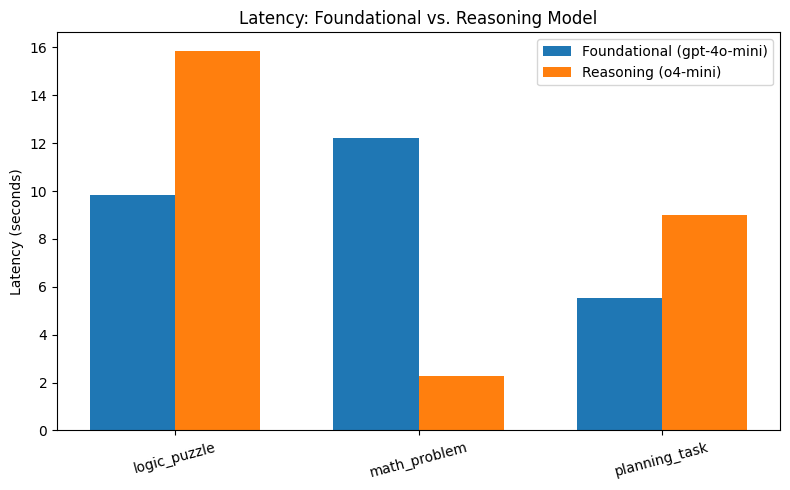

In [ ]:
 #Plotting the latency for all 6 permutations

import matplotlib.pyplot as plt
import numpy as np

tasks = list(prompts.keys())
foundational_times = [next(r["elapsed_sec"] for r in results if r["task"] == t and r["type"] == "foundational") for t in tasks]
reasoning_times    = [next(r["elapsed_sec"] for r in results if r["task"] == t and r["type"] == "reasoning") for t in tasks]

x = np.arange(len(tasks))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, foundational_times, width, label=f"Foundational ({FOUNDATIONAL_MODEL})")
ax.bar(x + width/2, reasoning_times, width, label=f"Reasoning ({REASONING_MODEL})")
ax.set_ylabel("Latency (seconds)")
ax.set_title("Latency: Foundational vs. Reasoning Model")
ax.set_xticks(x)
ax.set_xticklabels(tasks, rotation=15)
ax.legend()
plt.tight_layout()
plt.show()

In [2]:
# Fixed dictionary key to match REASONING_MODEL = "o1-mini"
OPENAI_PRICING = {
    'gpt-4o-mini': {
        'input': 0.15,
        'output': 0.60,
        'reasoning': 0.0,
    },
    'o1-mini': {  # Fixed from 'o4-mini' to 'o1-mini'
        'input': 0.15,
        'output': 0.60,
        'reasoning': 1.00,
    }
}

for model, rates in OPENAI_PRICING.items():
    for token_type, cost in rates.items():
        OPENAI_PRICING[model][token_type] = cost / 1_000_000

def calculate_cost(model_name, prompt_tokens, completion_tokens, reasoning_tokens):
    pricing = OPENAI_PRICING.get(model_name)
    if not pricing:
        print(f"Warning: Pricing not found for model {model_name}. Cost will be 0.")
        return 0.0

    input_cost = prompt_tokens * pricing['input']
    output_cost = completion_tokens * pricing['output']
    reasoning_cost = reasoning_tokens * pricing.get('reasoning', 0.0)

    return input_cost + output_cost + reasoning_cost

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'metrics_df' in globals() and not metrics_df.empty and 'model' in metrics_df.columns:
    cost_per_model_type = metrics_df.groupby(['model', 'type'])['cost'].sum().reset_index()

    plt.figure(figsize=(10, 6))
    sns.barplot(
        x='model',
        y='cost',
        hue='type',
        data=cost_per_model_type,
        palette='pastel',
        dodge=False
    )

    plt.title('Total Cost per Model by Type')
    plt.xlabel('Model')
    plt.ylabel('Total Cost (USD)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Type')
    plt.tight_layout()
    plt.show()
else:
    print("No metrics data available to render stacked bar chart.")

No metrics data available to render stacked bar chart.
